In [1]:
from qc_grader.challenges.fallfest_2026 import check_progress


from qc_grader.challenges.fallfest_2026.intro import (
    grade_intro_ex1, grade_intro_ex2, grade_intro_ex3, grade_intro_ex4,
    grade_intro_ex5, grade_intro_ex6, grade_intro_ex7, grade_intro_ex8,
    grade_intro_ex9, grade_intro_ex10, grade_intro_ex11, grade_intro_ex12,
    grade_intro_ex13, grade_intro_ex14,
)

In [2]:
from qiskit import QuantumCircuit

circuit_a = QuantumCircuit(1,1)
circuit_b = QuantumCircuit(1,1)
circuit_c = QuantumCircuit(1,1)

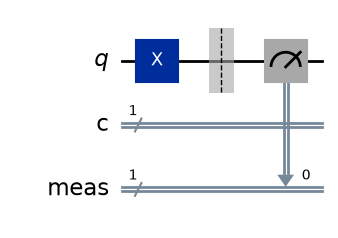

In [3]:
circuit_a.x(0)
circuit_a.measure_all()
circuit_a.draw("mpl")

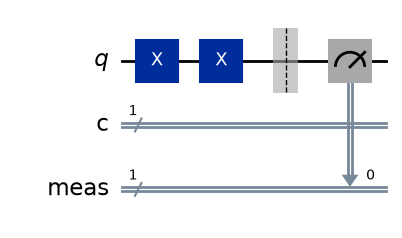

In [4]:
circuit_b.x(0)
circuit_b.x(0)
circuit_b.measure_all()
circuit_b.draw("mpl")

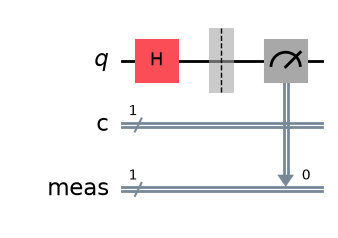

In [5]:
circuit_c.h(0)
circuit_c.measure_all()
circuit_c.draw("mpl")

Circuit-A: Expecting 1 on all 100 shots

Circuit-B: Expecting 0 on all 100 shots

Circuit-C: Out of 100 shots expecting 50 0's and 50 1's

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService

In [7]:
service = QiskitRuntimeService()

In [8]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

backend = service.least_busy()
print(backend.name)

ibm_fez


In [9]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qc_isa_a = pm.run(circuit_a)
qc_isa_b = pm.run(circuit_b)
qc_isa_c = pm.run(circuit_c)

In [19]:
sampler = Sampler(mode=backend)
pubs = [qc_isa_a,qc_isa_b,qc_isa_c]
jobs = sampler.run(pubs,shots=100)
res = jobs.result()
counts_a = res[0].data.meas.get_counts()
counts_b = res[1].data.meas.get_counts()
counts_c = res[2].data.meas.get_counts()

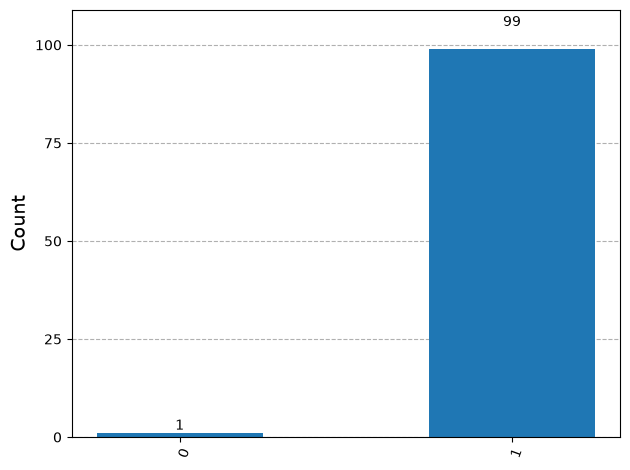

In [20]:
from qiskit.visualization import plot_histogram

plot_histogram(counts_a)

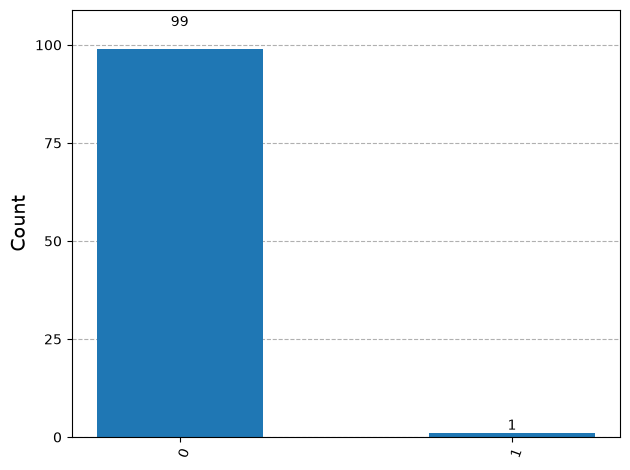

In [21]:
plot_histogram(counts_b)

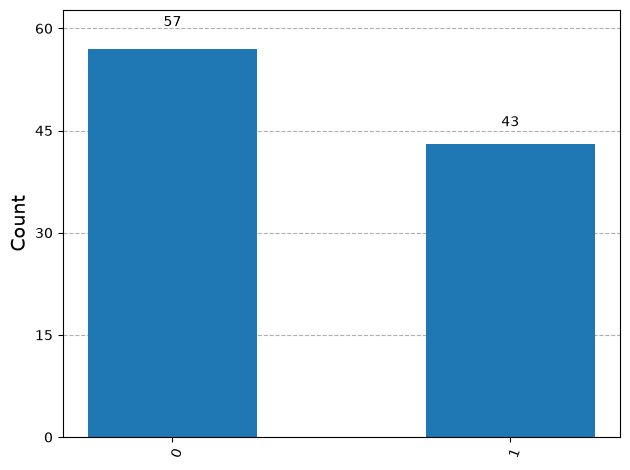

In [22]:
plot_histogram(counts_c)

Actual Results: 

Circuit A - 1 0's and 99 1's

Circuit B - 99 0's and 1 1

Circuit C - 57 0's and 43 1's

- A clear change is observed in circuit a and c, but the circuit b result is as predicted. This is due to the noise as we execute the code again and again these predicted values will also change, but there will be some noise the actual results might not match the exact predicted results always.